# Place Name Normalization

The resulting dataset (`data/clean/unique_places.csv`) serves as the authoritative lookup table for all place references across the project, enabling consistent spatial analysis and record linkage.

Historical documents present significant challenges in place name identification due to spelling variations, ambiguous toponyms, and evolving geographic nomenclature. This notebook establishes an authoritative gazetteer of unique places mentioned in the Sondondo sacramental records through a two-phase approach:

2. **Manual curation**: Apply expert knowledge to disambiguate problematic cases and link canonical forms to authoritative geographic databases (GeoNames, Getty TGN, World Historical Gazetteer, Wikidata)
1. **Automated extraction**: Identify and preliminarily resolve place mentions using the `placeRecognition` module

## Data Preparation

We begin by loading the cleaned sacramental records, which have already undergone date normalization and attribute harmonization. Place names at this stage retain their original spelling variations as recorded in the historical documents.

In [39]:
import pandas as pd

In [40]:
PLACES_MAP = '../data/mappings/places_types.json'

In [3]:
BAUTISMOS_HARMONIZED = pd.read_csv("../data/clean/bautismos_clean.csv")
MATRIMONIOS_HARMONIZED = pd.read_csv("../data/clean/matrimonios_clean.csv")
ENTIERROS_HARMONIZED = pd.read_csv("../data/clean/entierros_clean.csv")

BAUTISMOS_HARMONIZED

,file,identifier,event_type,event_date,baptized_name,baptized_birth_place,baptized_birth_date,baptized_legitimacy_status,father_name,father_lastname,...,godfather_social_condition,godmother_name,godmother_lastname,godmother_social_condition,event_place,event_geographic_descriptor_1,event_geographic_descriptor_2,event_geographic_descriptor_3,event_geographic_descriptor_4,baptized_lastname
0,APAucará LB L001,B001,Bautizo,1790-10-04,domingo,NaN,1790-08-04,Hijo legitimo,lucas,ayquipa,...,NaN,NaN,NaN,NaN,Pampamarca,Aucara,Pampamarca,NaN,NaN,ayquipa
1,APAucará LB L001,B002,Bautizo,1790-10-06,dominga,NaN,1790-08-04,Hija legitima,juan,lulia,...,NaN,NaN,NaN,NaN,Pampamarca,Aucara,Pampamarca,NaN,NaN,lulia
2,APAucará LB L001,B003,Bautizo,1790-10-07,bartola,NaN,1790-08-04,Hija legitima,jacinto,quispe,...,NaN,rotonda,pocco,NaN,Pampamarca,Aucara,Pampamarca,NaN,NaN,quispe
3,APAucará LB L001,B004,Bautizo,1790-10-20,francisca,NaN,1790-10-15,Hija legitima,juan,cuebas,...,NaN,ysabel,guillen,NaN,Aucara,Aucara,NaN,NaN,NaN,cuebas
4,APAucará LB L001,B005,Bautizo,1790-10-20,pedro,NaN,1790-10-19,Hijo legitimo,santos,manxo,...,NaN,josefa,santiago,NaN,Aucara,Aucara,NaN,NaN,NaN,manxo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6335,APAucará LB L004,B2042,Bautizo,1888-12-10,leocadio,NaN,1888-12-09,"Hijo natural, mestizo",miguel,pacheco,...,NaN,NaN,NaN,NaN,Aucará,Aucará,Aucará,NaN,NaN,pacheco
6336,APAucará LB L004,B2043,Bautizo,1888-12-11,mariano concepcion,NaN,1888-12-07,"Hijo legítimo, indio",facundo,vega,...,NaN,NaN,NaN,NaN,Aucará,Aucará,Aucará,NaN,NaN,vega
6337,APAucará LB L004,B2044,Bautizo,1888-12-12,ambrosio,NaN,1888-12-06,"Hijo legítimo, indio",ysidro,ccasane,...,NaN,NaN,NaN,NaN,Aucará,Aucará,Mayobamba,NaN,NaN,ccasane
6338,APAucará LB L004,B2045,Bautizo,1888-12-15,francisco,NaN,1888-11-30,"Hijo legítimo, indio",mariano,lopez,...,Indigna de Huaicahuacho,NaN,NaN,NaN,Aucará,Aucará,Huaicahuacho,NaN,NaN,lopez


## Automated Place Extraction

The `PlaceExtractor` identifies place mentions within text fields and applies initial normalization using the geographic type taxonomy defined in `places_types.json`. This automated process handles straightforward cases but requires manual review for ambiguous toponyms.

We systematically process all place-related columns across the three sacramental record types, applying the extractor to standardize formatting and identify geographic descriptors.

### Extract Place Mentions

In [4]:
from actions.extractors import placeRecognition

extractor = placeRecognition.PlaceExtractor()

#### Baptismal Records

In [5]:
bautismos_place_columns = [
    'baptized_birth_place', 'event_place', 'event_geographic_descriptor_1',
        'event_geographic_descriptor_2', 'event_geographic_descriptor_3',
        'event_geographic_descriptor_4'
]

for col in bautismos_place_columns:
    if col in BAUTISMOS_HARMONIZED.columns:
        BAUTISMOS_HARMONIZED[col] = BAUTISMOS_HARMONIZED[col].apply(
            lambda x: x if len(str(x)) > 2 else None
        )
        BAUTISMOS_HARMONIZED[col] = extractor.extract_places_per_row(BAUTISMOS_HARMONIZED[col])

BAUTISMOS_HARMONIZED[bautismos_place_columns]

,baptized_birth_place,event_place,event_geographic_descriptor_1,event_geographic_descriptor_2,event_geographic_descriptor_3,event_geographic_descriptor_4
0,NaN,Pampamarca,Aucara,Pampamarca,NaN,NaN
1,NaN,Pampamarca,Aucara,Pampamarca,NaN,NaN
2,NaN,Pampamarca,Aucara,Pampamarca,NaN,NaN
3,NaN,Aucara,Aucara,NaN,NaN,NaN
4,NaN,Aucara,Aucara,NaN,NaN,NaN
...,...,...,...,...,...,...
6335,NaN,Aucará,Aucará,Aucará,NaN,NaN
6336,NaN,Aucará,Aucará,Aucará,NaN,NaN
6337,NaN,Aucará,Aucará,Mayobamba,NaN,NaN
6338,NaN,Aucará,Aucará,Huaicahuacho,NaN,NaN


#### Marriage Records

In [6]:
matrimonios_place_columns = [
    'husband_birth_place',
       'husband_resident_in', 
       'wife_birth_place', 'wife_resident_in', 
       'event_place', 'event_geographic_descriptor_1', 'event_geographic_descriptor_2',
       'event_geographic_descriptor_3', 'event_geographic_descriptor_4',
       'event_geographic_descriptor_5', 'event_geographic_descriptor_6'
]

for col in matrimonios_place_columns:
    if col in MATRIMONIOS_HARMONIZED.columns:
        MATRIMONIOS_HARMONIZED[col] = MATRIMONIOS_HARMONIZED[col].apply(
            lambda x: x if len(str(x)) > 2 else None
        )
        MATRIMONIOS_HARMONIZED[col] = extractor.extract_places_per_row(MATRIMONIOS_HARMONIZED[col])

MATRIMONIOS_HARMONIZED[matrimonios_place_columns]

,husband_birth_place,husband_resident_in,wife_birth_place,wife_resident_in,event_place,event_geographic_descriptor_1,event_geographic_descriptor_2,event_geographic_descriptor_3,event_geographic_descriptor_4,event_geographic_descriptor_5,event_geographic_descriptor_6
0,Ciudad de Huamanga,Aucara,NaN,NaN,Aucara,Aucara,Huamanga,Coracora,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,Aucara,Aucara,Colca,NaN,NaN,NaN,NaN
2,Pampamarca,NaN,Pampamarca,NaN,Aucara,Aucara,Pampamarca,NaN,NaN,NaN,NaN
3,Pampamarca,NaN,Pampamarca,NaN,Pampamarca|santa iglesia,Aucara,Pampamarca,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,Pampamarca|santa iglesia,Aucara,Pampamarca,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1714,Pampamarca,NaN,Pampamarca,NaN,Pampamarca,Aucara,Pampamarca,NaN,NaN,NaN,NaN
1715,Chacralla,NaN,Chacralla,NaN,"Chacralla, iglesia vice-parroquial",Aucara,Chacralla,NaN,NaN,NaN,NaN
1716,Chacralla,NaN,Chacralla,NaN,"Chacralla, iglesia vice-parroquial",Aucara,Chacralla,NaN,NaN,NaN,NaN
1717,NaN,Aucara,NaN,Aucara,Aucara,Aucara,Queca,NaN,NaN,NaN,NaN


#### Burial Records

In [7]:
entierros_place_columns = [
    'event_place', 'deceased_birth_place', 'burial_place', 'event_geographic_descriptor_1',
    'event_geographic_descriptor_2', 'event_geographic_descriptor_3',
    'event_geographic_descriptor_4'
]

for col in entierros_place_columns:
    if col in ENTIERROS_HARMONIZED.columns:
        ENTIERROS_HARMONIZED[col] = ENTIERROS_HARMONIZED[col].apply(
            lambda x: x if len(str(x)) > 2 else None
        )
        ENTIERROS_HARMONIZED[col] = extractor.extract_places_per_row(ENTIERROS_HARMONIZED[col])

ENTIERROS_HARMONIZED[entierros_place_columns]

,event_place,deceased_birth_place,burial_place,event_geographic_descriptor_1,event_geographic_descriptor_2,event_geographic_descriptor_3,event_geographic_descriptor_4
0,NaN,NaN,NaN,Aucará,Lucanas,NaN,NaN
1,NaN,NaN,NaN,Aucará,Lucanas,NaN,NaN
2,NaN,NaN,NaN,Aucará,Lucanas,NaN,NaN
3,NaN,NaN,NaN,Aucará,Lucanas,NaN,NaN
4,NaN,NaN,NaN,Aucará,Lucanas,NaN,NaN
...,...,...,...,...,...,...,...
2187,Aucara,Santa Ana de Aucara,NaN,Aucara,Santa Ana de Aucara,NaN,NaN
2188,Aucara,Pampamarca,NaN,Aucara,Pampamarca,NaN,NaN
2189,Aucara,Santa Ana de Aucara,NaN,Aucara,Santa Ana de Aucara,NaN,NaN
2190,Aucara,Aucara,NaN,Aucara,NaN,NaN,NaN


### Consolidate and Resolve Places

The `MapPlaces` class aggregates all place mentions from the three datasets, identifies unique toponyms, and attempts automated resolution against authoritative gazetteers. The output is suppressed here as it produces verbose logging; results are saved for subsequent manual review.

In [8]:
%%capture

bautismos_places = BAUTISMOS_HARMONIZED[bautismos_place_columns]
matrimonios_places = MATRIMONIOS_HARMONIZED[matrimonios_place_columns] 
entierros_places = ENTIERROS_HARMONIZED[entierros_place_columns]

map_places = placeRecognition.MapPlaces([bautismos_places, matrimonios_places, entierros_places], places_map=PLACES_MAP)
all_unique_places = map_places.resolve_places()
print("All unique places extracted:")
print(all_unique_places)

In [9]:
all_unique_places.to_csv("../data/interim/unique_places.csv", index=False)

In [10]:
standardized_places = all_unique_places.loc[all_unique_places['uri'].notna()]
standardized_places.groupby('uri').first().reset_index().sort_values(by='standardize_label').to_csv("../data/interim/standardized_places.csv", index=False)

## Manual Curation and Authority Control

Automated place resolution, while effective for unambiguous cases, cannot handle toponymic challenges such as:

- **Homonyms**: Multiple places sharing the same name (e.g., "Pampamarca" appears in multiple regions)
- **Historical name changes**: Places known by different names across time periods
- **Spelling variations**: Inconsistent orthography in colonial records (e.g., "Ishua" vs "Ischua")
- **Ambiguous references**: Generic descriptors that could refer to multiple locations

To address these issues, we created `data/interim/unique_places_manual.csv`, an authority file that maps variant forms (`mentioned_as`) to canonical place names with verified geographic coordinates and gazetteer identifiers.

### Validation Against Manual Normalization

We compare the automated extraction results against the manually curated authority file to identify discrepancies and ensure completeness.

In [20]:
uplaces = pd.read_csv('../data/interim/unique_places_manual.csv')
set_diff = set(standardized_places['standardize_label']) - set(uplaces['manually_normalized_place'])

In [12]:
set_diff

{'Cajamarca',
 'Ceibo Roto',
 'Ciudad Libertad de las Américas',
 'Córdova',
 'Dos de Mayo',
 'Huanacopampa',
 'India Muerta',
 'Indio Piro',
 'Julca',
 'Paico',
 'Pampa Grande',
 'Poma Patacollo',
 'San Juan',
 'San Pedro de Lloc',
 'Santa Anita - Los Ficus',
 'Santa Iglesia',
 'Santa María',
 'Taulli',
 'Villa San Juan',
 'Yanaccollpa'}

### Authoritative Place Resolution

The `AuthoritativePlaceResolver` applies the manually curated authority file to resolve all place mentions. For each canonical place name, it queries multiple authoritative gazetteers in priority order:

1. **GeoNames** - comprehensive global gazetteer with detailed administrative hierarchies
2. **Getty Thesaurus of Geographic Names (TGN)** - art historical geographic authority
3. **World Historical Gazetteer (WHG)** - specialized in historical place names
4. **Wikidata** - linked data resource with extensive geographic coverage

This process produces `data/clean/unique_places.csv`, the authoritative lookup table linking historical place mentions to verified geographic entities with coordinates, hierarchical context, and stable identifiers.

**Note**: We extended `places_types.json` to include "administrative division" as a recognized geographic type, enabling better classification of jurisdictional references in the historical records:

```json
"administrative division": {
    "geonames": "A",
    "wikidata": "Q5",
    "tgn": "administrative divisions",
    "whg": "a"
  }
```

In [41]:
%%capture

manual_data = pd.read_csv('../data/interim/unique_places_manual.csv')

resolver = placeRecognition.AuthoritativePlaceResolver(data=manual_data, places_map=PLACES_MAP)
result_df = resolver.resolve_places()

print("Resolved places:")
print(result_df)

## Database Integration

To prepare the gazetteer for relational database storage, we assign a unique integer identifier (`place_id`) to each canonical place. This serves as the primary key in the places table and enables efficient joins with sacramental records.

In [42]:
result_df['place_id'] = result_df.index + 1
result_df = result_df.set_index('place_id')

result_df

,manually_normalized_place,standardize_label,language,latitude,longitude,source,id,uri,country_code,part_of,part_of_uri,confidence,threshold,match_type,mentioned_as
place_id,,,,,,,,,,,,,,,
1,Acobamba,Acobamba,es,-12.07757,-74.87127,GeoNames,8663907.0,http://sws.geonames.org/8663907/,PE,,,100.0,90.0,exact,[Acobamba]
4,Andamarca,Andamarca,es,-15.63833,-70.58848,GeoNames,3947725.0,http://sws.geonames.org/3947725/,PE,,,100.0,90.0,exact,[Andamarca]
6,Apongo,Apongo,es,-14.01327,-73.93247,GeoNames,3947431.0,http://sws.geonames.org/3947431/,PE,,,100.0,90.0,exact,[Apongo]
8,Aucará,Aucará,es,-14.25000,-74.08333,GeoNames,3947087.0,http://sws.geonames.org/3947087/,PE,,,100.0,90.0,exact,"[Aucara, Aucara Barrio de Mayo, Aucará, Barrio..."
9,Cabana,Cabana,es,-15.64288,-70.27983,GeoNames,8349755.0,http://sws.geonames.org/8349755/,PE,,,100.0,90.0,exact,"[Aucara Cabana, Cabana]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,Sondondo,Sondondo,es,-14.29795,-73.93928,GeoNames,3928450.0,http://sws.geonames.org/3928450/,PE,,,100.0,90.0,exact,[Sondondo]
80,Soras Pata,Soras Pata,es,-14.23741,-70.65011,GeoNames,13238703.0,http://sws.geonames.org/13238703/,PE,,,100.0,90.0,exact,[Soras]
82,Umasi,Umasi,es,-14.89142,-70.68701,GeoNames,13238711.0,http://sws.geonames.org/13238711/,PE,,,100.0,90.0,exact,"[Umaci, Umasi]"


In [43]:
result_df.to_csv("../data/interim/unique_places_consolidated.csv", index=True)

## Visual Checking and Manual Corrections

Despite this iterative process, some places are not accurately resolved. A visual inspection of the geographic distribution helps to identify outliers and potential errors in the place mapping. This plot shows the resulting geographic distribution of `unique_places_consolidated.csv` before manual corrections:

In [45]:
import numpy as np
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

In [46]:
def plot_places_on_map(people_places_dataframe, place_column='place_name', map_title='Plot of Places'):

    gdf = gpd.GeoDataFrame(
        people_places_dataframe,
        geometry=gpd.points_from_xy(
            people_places_dataframe.longitude, 
            people_places_dataframe.latitude
            ),
        crs="EPSG:4326"
    ).to_crs(epsg=3857)  # Web Mercator for contextily tiles

    fig, ax = plt.subplots(figsize=(10, 8))

    gdf.plot(
        ax=ax,
        color='#333333',
        alpha=0.7,
        edgecolor='white',
        linewidth=0.4
    )
    
    for _, row in gdf.iterrows():
        ax.annotate(
            row[place_column],
            xy=(row.geometry.x, row.geometry.y),
            xytext=(4, 4),
            textcoords='offset points',
            fontsize=7,
            color='#333333'
        )
    
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron) # type: ignore
    ax.set_axis_off()
    ax.set_title(map_title, fontsize=14)

    fig.tight_layout()
    plt.show()

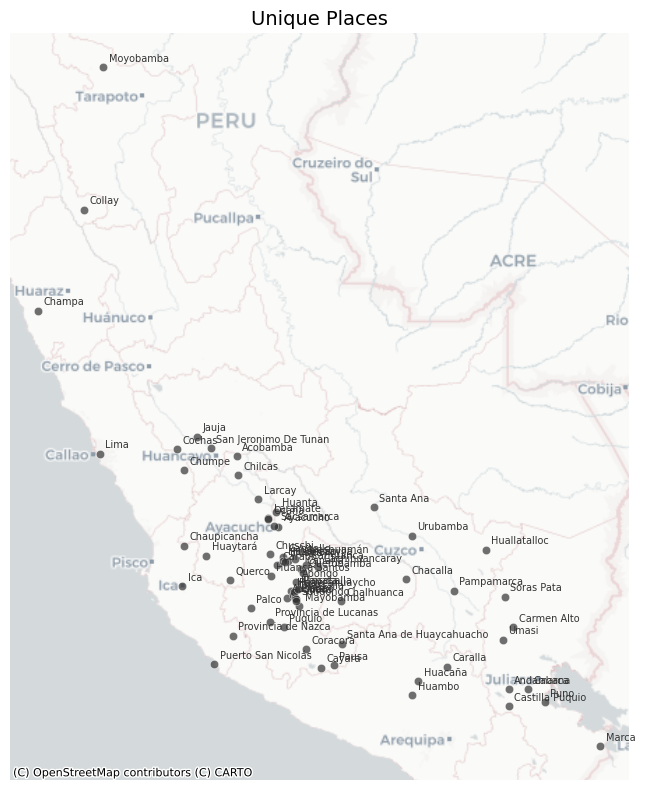

In [47]:
plot_places_on_map(result_df, place_column='standardize_label', map_title='Unique Places')

Outliers and misplacements can be identified through this visualization. The list of places that require manual correction is:

In [51]:
places_to_fix = [
    {
        'place_name': 'Moyobamba',
        'correct_name': 'Moyobamba',
        'latitude': -14.37597,
        'longitude': -73.89332,
        'source': 'GeoNames',
        'id': 3959819,
        'uri': 'http://sws.geonames.org/3959819/'
    },
    {
        'place_name': 'Champa',
        'correct_name': 'Santa Isabel de Chapa',
        'latitude': -14.2757613,
        'longitude': -74.0158869,
        'source': 'OpenStreetMap',
        'id': 3588141573,
        'uri': 'https://www.openstreetmap.org/node/3588141573#map=18/-14.275680/-74.015896'
    },
    {
        'place_name': 'Pampamarca',
        'correct_name': 'Pampamarca',
        'latitude': -14.23287,
        'longitude': -74.04139,
        'source': 'GeoNames',
        'id': 13580561,
        'uri': 'http://sws.geonames.org/13580561/'
    }
]

In [52]:
# Replace the incorrect entries in the result_df with the corrected information
for place in places_to_fix:
    mask = result_df['standardize_label'] == place['place_name']
    result_df.loc[mask, 'standardize_label'] = place['correct_name']
    result_df.loc[mask, 'latitude'] = place['latitude']
    result_df.loc[mask, 'longitude'] = place['longitude']
    result_df.loc[mask, 'source'] = place['source']
    result_df.loc[mask, 'id'] = place['id']
    result_df.loc[mask, 'uri'] = place['uri']
    
result_df.to_csv("../data/clean/places.csv", index=True)

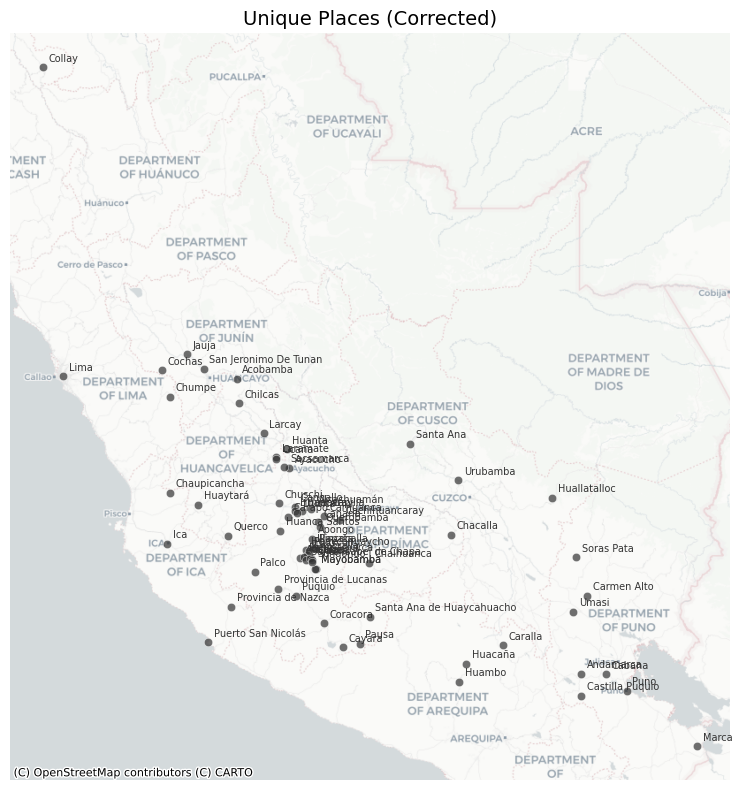

In [53]:
# visually check the corrected places on the map
plot_places_on_map(result_df, place_column='standardize_label', map_title='Unique Places (Corrected)')